# Leitura de Dados

In [2]:
import pandas as pd

In [3]:
dados_central = pd.read_csv("C:/Users/erick/OneDrive/Área de Trabalho/IC/Dados_TCGA/tpm_unstranded.csv/tpm_unstranded.csv")

In [4]:
# dados_central.head()
# dados_central.isna().sum()
dados_central.iloc[:, 284].std()

0.0

### Quantidade de amostras por classe em cada cliente

In [6]:
contagens = dados_central.groupby(['tss', 'subtipo2']).size().to_frame(name = 'Count').reset_index().pivot(index = 'tss', columns='subtipo2', values='Count')
contagens = contagens.fillna(value=0)
contagens['Total'] = contagens['BRCA.Basal'] +  contagens['BRCA.Her2'] + contagens['BRCA.LumA'] + contagens['BRCA.LumB']

In [7]:
# contagens

### Clientes com 3 ou mais amostras em cada classe são incluídos no treinamento do AF

In [9]:
contagens['Função'] = contagens.gt(2).all(axis = 1).replace({True : 'Treino e Teste', False: 'Teste'})
contagens = contagens.sort_values(by= ['Função', 'Total'], ascending=False)
contagens['index'] = list(range(1,len(contagens)+1))
contagens = contagens.reset_index()

In [10]:
contagens

subtipo2,tss,BRCA.Basal,BRCA.Her2,BRCA.LumA,BRCA.LumB,Total,Função,index
0,BH,20.0,8.0,100.0,25.0,153.0,Treino e Teste,1
1,A2,24.0,8.0,44.0,19.0,95.0,Treino e Teste,2
2,E2,18.0,6.0,53.0,15.0,92.0,Treino e Teste,3
3,A8,5.0,9.0,36.0,33.0,83.0,Treino e Teste,4
4,D8,11.0,6.0,37.0,23.0,77.0,Treino e Teste,5
5,AR,16.0,4.0,31.0,15.0,66.0,Treino e Teste,6
6,B6,15.0,4.0,30.0,8.0,57.0,Treino e Teste,7
7,C8,6.0,15.0,12.0,14.0,47.0,Treino e Teste,8
8,AC,7.0,3.0,32.0,3.0,45.0,Treino e Teste,9
9,AO,8.0,3.0,20.0,11.0,42.0,Treino e Teste,10


In [11]:
tt_tss = contagens.loc[contagens['Função'] == 'Treino e Teste', ['index','tss']]
t_tss = contagens.loc[contagens['Função'] == 'Teste', ['index','tss']]

## Divisão em Treino (60%), Validação (20%) e Teste (20%) feita de forma estratificada para garantir todas as classes em todas as divisões.

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
lista_conj_treino, lista_conj_valid, lista_conj_teste = [], [], []
for i in range(len(tt_tss['tss'])):
    dados_cliente = dados_central[dados_central['tss'] == tt_tss['tss'][i]]
    conj_treino_cliente, conj_teste_cliente = train_test_split(dados_cliente, test_size=0.2, random_state=i, stratify=dados_cliente['subtipo2'])
    conj_treino_cliente, conj_valid_cliente = train_test_split(conj_treino_cliente, test_size=0.25, random_state=1000+i, stratify=conj_treino_cliente['subtipo2'])
    conj_treino_cliente.to_csv(f'fl_conj_treino_{tt_tss['tss'][i]}.csv', index = False)
    conj_valid_cliente.to_csv(f'fl_conj_valid_{tt_tss['tss'][i]}.csv', index = False)
    conj_teste_cliente.to_csv(f'fl_conj_teste_{tt_tss['tss'][i]}.csv', index = False)
    lista_conj_treino.append(conj_treino_cliente)
    lista_conj_valid.append(conj_valid_cliente)
    lista_conj_teste.append(conj_teste_cliente)
conj_treino = pd.concat(lista_conj_treino, ignore_index=True)
conj_valid = pd.concat(lista_conj_valid, ignore_index=True)
conj_teste = pd.concat(lista_conj_teste, ignore_index=True)

In [15]:
import numpy as np
mean = np.mean(conj_treino.iloc[:, 5:], axis = 0)
var = np.var(conj_treino.iloc[:, 5:], axis = 0)
std = np.std(conj_treino.iloc[:, 5:], axis = 0)

In [16]:
np.save("std_central", mean)
np.save("var_central", var)
np.save("mean_central", std)

In [17]:
max(std)

26287.796153405805

In [18]:
tt_tss['tss']

0     BH
1     A2
2     E2
3     A8
4     D8
5     AR
6     B6
7     C8
8     AC
9     AO
10    EW
Name: tss, dtype: object

### Clientes que não participam do treino no AF são incluídos no conjunto de treino no AM. Dessa forma, os conjuntos de teste são iguais.

In [52]:
for i in range(len(t_tss['tss']) - len(tt_tss['tss'])):
    dados_cliente = dados_central[dados_central['tss'] == t_tss['tss'][i+11]]
    dados_cliente.to_csv(f'fl_conj_total_{t_tss['tss'][i+11]}.csv', index = False)
    lista_conj_treino.append(dados_cliente)
conj_treino = pd.concat(lista_conj_treino, ignore_index=True)

### Pré-processamento

In [54]:
from sklearn.preprocessing import LabelEncoder

In [56]:
x_treino, y_treino = conj_treino.iloc[:, 5:], conj_treino['subtipo2']
x_valid, y_valid = conj_valid.iloc[:, 5:], conj_valid['subtipo2']
x_teste, y_teste = conj_teste.iloc[:, 5:], conj_teste['subtipo2']
ee = LabelEncoder()
y_treino_enc = ee.fit_transform(y_treino)
y_valid_enc = ee.transform(y_valid)
y_teste_enc = ee.transform(y_teste)

### Padronização dos dados

In [58]:
from sklearn.preprocessing import StandardScaler

In [59]:
scaler = StandardScaler()
x_treino_sc = scaler.fit_transform(x_treino)
x_valid_sc = scaler.transform(x_valid)
x_teste_sc = scaler.transform(x_teste)

### Autoencoder

In [62]:
import keras
from keras import layers
from keras import regularizers

In [100]:
input_layer = keras.Input(shape = (60660,))
encoded = layers.Dense(300, activation = 'relu', kernel_regularizer = regularizers.L1(1e-5))(input_layer)
decoded = layers.Dense(60660, activation='sigmoid')(encoded)
autoencoder = keras.Model(input_layer, decoded)
encoder = keras.Model(input_layer, encoded)
encoded_input = keras.Input(shape=(300,))
decoder_layer = autoencoder.layers[-1]
decoder = keras.Model(encoded_input, decoder_layer(encoded_input))
autoencoder.compile(optimizer=keras.optimizers.SGD(learning_rate = 1e-3), loss='mse')
autoencoder.fit(x_treino_sc, x_treino_sc,
                epochs=15,
                batch_size=256,
                validation_data=(x_valid_sc, x_valid_sc))

Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - loss: 2.0085 - val_loss: 5.5610
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 697ms/step - loss: 1.6007 - val_loss: 5.2600
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 640ms/step - loss: 1.2816 - val_loss: 5.1290
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 639ms/step - loss: 1.1789 - val_loss: 5.0757
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 669ms/step - loss: 1.1704 - val_loss: 5.0519
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 636ms/step - loss: 1.0840 - val_loss: 5.0058
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 647ms/step - loss: 1.0865 - val_loss: 4.9658
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 666ms/step - loss: 1.0567 - val_loss: 4.9386
Epoch 9/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 635ms/step - loss: 0.9587 - val_loss: 4.9290
Epoch 10/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 639ms/step - loss: 1.0053 - val_loss: 4.9157
Epoch 11/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 674ms/step - loss: 1.0115 - val_loss: 4.9049
Epoch 12/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 656ms/step - loss: 0.9885 - val_loss:

In [102]:
x_treino_ac = encoder.predict(x_treino_sc)
x_valid_ac = encoder.predict(x_valid_sc)
x_teste_ac = encoder.predict(x_teste_sc)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


### Análise de Componentes Principais

In [84]:
from sklearn.decomposition import PCA

In [86]:
pca = PCA(random_state=1)
x_treino_pca = pca.fit_transform(x_treino_sc)
x_valid_pca = pca.transform(x_valid_sc)
x_teste_pca = pca.transform(x_teste_sc)

In [87]:
import matplotlib.pyplot as plt

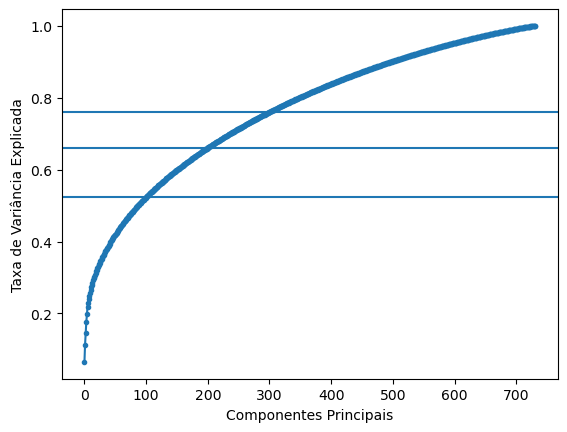

In [88]:
plt.plot(pca.explained_variance_ratio_.cumsum(), marker = '.')
plt.xlabel('Componentes Principais')
plt.ylabel('Taxa de Variância Explicada')
plt.axhline(y = pca.explained_variance_ratio_.cumsum()[100], xmin = 0, xmax = 1000)
plt.axhline(y = pca.explained_variance_ratio_.cumsum()[200], xmin = 0, xmax = 1000)
plt.axhline(y = pca.explained_variance_ratio_.cumsum()[300], xmin = 0, xmax = 1000)
plt.show()

In [89]:
pca = PCA(n_components=300)
x_treino_pca = pca.fit_transform(x_treino_sc)
x_valid_pca = pca.transform(x_valid_sc)
x_teste_pca = pca.transform(x_teste_sc)

In [55]:
np.save("comp_pca_central", pca.components_)

### Oversampling

In [120]:
from imblearn.over_sampling import ADASYN

In [159]:
adasyn_ac = ADASYN(random_state = 1, n_neighbors = 5)
x_treino_ac_resampled, y_treino_ac_resampled = adasyn_ac.fit_resample(x_treino_ac, y_treino)
adasyn_pca = ADASYN(random_state = 1, n_neighbors = 5)
x_treino_pca_resampled, y_treino_pca_resampled = adasyn_pca.fit_resample(x_treino_pca, y_treino)

### Regressão Logística (Com regularização L1)

In [74]:
from sklearn.linear_model import LogisticRegression

In [165]:
rl = LogisticRegression(penalty='l1', random_state=1, solver = 'saga', max_iter = 100, C = 0.01)
rl.fit(x_treino_pca_resampled, y_treino_pca_resampled)

C:\Users\erick\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(C=0.01, penalty='l1', random_state=1, solver='saga')

In [78]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [167]:
print(confusion_matrix(y_valid, rl.predict(x_valid_pca)))
print(classification_report(y_true=y_valid, y_pred=rl.predict(x_valid_pca)))

[[28  0  0  0]
 [ 0 12  0  3]
 [ 0  2 73  9]
 [ 0  4  5 27]]
              precision    recall  f1-score   support

  BRCA.Basal       1.00      1.00      1.00        28
   BRCA.Her2       0.67      0.80      0.73        15
   BRCA.LumA       0.94      0.87      0.90        84
   BRCA.LumB       0.69      0.75      0.72        36

    accuracy                           0.86       163
   macro avg       0.82      0.85      0.84       163
weighted avg       0.87      0.86      0.86       163



### Support Vector Machine

In [110]:
from sklearn.svm import SVC

In [111]:
svm = SVC(C = 0.1, kernel = 'linear')
svm.fit(x_treino_ac, y_treino)

SVC(C=0.1, kernel='linear')

In [114]:
print(confusion_matrix(y_valid, svm.predict(x_valid_ac)))
print(classification_report(y_true = y_valid, y_pred = svm.predict(x_valid_ac)))

[[27  0  1  0]
 [ 1 11  0  3]
 [ 0  2 79  3]
 [ 0  3 11 22]]
              precision    recall  f1-score   support

  BRCA.Basal       0.96      0.96      0.96        28
   BRCA.Her2       0.69      0.73      0.71        15
   BRCA.LumA       0.87      0.94      0.90        84
   BRCA.LumB       0.79      0.61      0.69        36

    accuracy                           0.85       163
   macro avg       0.83      0.81      0.82       163
weighted avg       0.85      0.85      0.85       163



In [38]:
from sklearn.neighbors import KNeighborsClassifier

### KNN (Desempenho bem abaixo)

In [40]:
# knn = KNeighborsClassifier(n_neighbors = 20)
# knn.fit(x_treino_pca, y_treino)

In [41]:
# print(confusion_matrix(y_valid, knn.predict(x_valid_pca)))
# print(classification_report(y_true=y_valid, y_pred=knn.predict(x_valid_pca)))

In [42]:
from sklearn.naive_bayes import GaussianNB

In [43]:
# nb = GaussianNB()
# nb.fit(x_treino_pca, y_treino)

In [44]:
# print(confusion_matrix(y_valid, nb.predict(x_valid_pca)))
# print(classification_report(y_true=y_valid, y_pred=nb.predict(x_valid_pca)))

In [45]:
from sklearn.tree import DecisionTreeClassifier

In [46]:
# arvore = DecisionTreeClassifier(random_state = 1)
# arvore.fit(x_treino_pca, y_treino)

In [47]:
# confusion_matrix(y_valid, arvore.predict(x_valid_pca))
# print(classification_report(y_true=y_valid, y_pred=arvore.predict(x_valid_pca)))

In [48]:
from sklearn.ensemble import RandomForestClassifier

In [49]:
# rf = RandomForestClassifier(n_estimators = 100, random_state = 1)
# rf.fit(x_treino, y_treino)

In [50]:
# confusion_matrix(y_valid, rf.predict(x_valid_pca))
# print(classification_report(y_true = y_valid, y_pred = rf.predict(x_valid_pca)))

In [51]:
# confusion_matrix(y_valid, rf.predict(x_valid))
# print(classification_report(y_true = y_valid, y_pred = rf.predict(x_valid)))

# Grid Search

In [171]:
from sklearn.model_selection import PredefinedSplit
import numpy as np
import sklearn
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from scikeras.wrappers import KerasClassifier
import keras
from keras.callbacks import EarlyStopping
from keras import layers
from keras import regularizers

### Método de validação Holdout

In [180]:
ps = PredefinedSplit(np.hstack((np.ones(len(x_treino_ac_resampled))*(-1),np.ones(len(x_valid_pca))*0)))

### Função para gerar redes neurais para seleção de hiperparâmetros

In [182]:
def get_clf(hidden_layer_sizes, hidden_layer_num, regularizer):
    model = keras.Sequential()
    model.add(keras.Input(shape=(300,)))
    for i in range(hidden_layer_num):
        model.add(
            keras.layers.Dense(
                units=hidden_layer_sizes,
                activation='relu',
                kernel_regularizer = regularizer
        )
    )
    model.add(keras.layers.Dense(4, activation='softmax'))
    # model.compile(
    #     optimizer = keras.optimizers.SGD(learning_rate=learning_rate),
    #     loss='binary_crossentropy',
    #     metrics=['accuracy']
    return model

### Seleção de hiperparâmetros com dados tranformados por PCA

In [184]:
model_params = {
    'log_reg': {
        'model': Pipeline([
                           ('log_reg', LogisticRegression())]),
        'params': {
            'log_reg__C': [0.01, 0.1, 1, 10],
            'log_reg__penalty': ['l1', 'l2'],
            'log_reg__solver': ['saga'],
            'log_reg__random_state': [1]
        }
    },
    'svm': {
        'model': Pipeline([
                           ('SVC', SVC())]),
        'params': {
            'SVC__C': [0.1, 1, 10, 100, 1000],
            'SVC__kernel': ['linear', 'poly', 'rbf'],
            'SVC__random_state': [1]
        }
    },
    'knn': {
        'model': Pipeline([
                           ('KNN', KNeighborsClassifier())]),
        'params': {
            'KNN__n_neighbors': [1, 3, 5, 15]
        }
    },
    'naive_bayes': {
        'model': Pipeline([
                           ('nb', GaussianNB())]),
        'params': {}
    },  
    'tree': {
        'model': Pipeline([
                           ('dt', DecisionTreeClassifier())]),
        'params': {
            'dt__max_depth': [1, 3, 10, 15, None],
            'dt__min_samples_split': [2, 6, 10],
            'dt__random_state': [1]
        }
    },
    'random_forest': {
        'model': Pipeline([
                           ('rf', RandomForestClassifier())]),
        'params': {
            'rf__max_depth': [1, 3, 10, 15, None],
            'rf__min_samples_split': [2, 6, 10], 
            'rf__random_state': [1]
        }
    },
    'nn': {
        'model': Pipeline([
                           ('keras', KerasClassifier(model=get_clf, random_state = 1, loss='sparse_categorical_crossentropy', optimizer='sgd', verbose=False, epochs = 15,
                                           callbacks=[EarlyStopping(patience=10, restore_best_weights=True,monitor='loss')]))]),
        'params':{
            'keras__optimizer__learning_rate': [1e-2, 1e-1],
            'keras__model__hidden_layer_sizes': [16, 32, 64, 128],
            'keras__model__hidden_layer_num': [1, 2, 3, 4, 5],
            'keras__model__regularizer': [regularizers.L1(1e-2), regularizers.L1(1e-3)]
        }
    }
}
scores = []
for model_name, mp in model_params.items():
    clf = GridSearchCV(mp['model'], mp['params'], cv = ps, return_train_score=False, scoring = 'f1_weighted')
    clf.fit(pd.concat([pd.DataFrame(x_treino_ac_resampled), pd.DataFrame(x_valid_ac)]), pd.concat([y_treino_ac_resampled, y_valid]))
    scores.append({
    'model': model_name,
    'best_score': clf.best_score_,
    'best_params': clf.best_params_
    })
validacao = pd.DataFrame(scores, columns=['model', 'best_score', 'best_params'])
validacao

C:\Users\erick\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\erick\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\erick\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\erick\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\erick\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\erick\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter 

,model,best_score,best_params
0,log_reg,0.874979,"{'log_reg__C': 0.01, 'log_reg__penalty': 'l2',..."
1,svm,0.850957,"{'SVC__C': 0.1, 'SVC__kernel': 'linear', 'SVC_..."
2,knn,0.769582,{'KNN__n_neighbors': 5}
3,naive_bayes,0.797968,{}
4,tree,0.790575,"{'dt__max_depth': 10, 'dt__min_samples_split':..."
5,random_forest,0.856157,"{'rf__max_depth': 10, 'rf__min_samples_split':..."
6,nn,0.862772,"{'keras__model__hidden_layer_num': 1, 'keras__..."


In [1]:
v

NameError: name 'validacao' is not defined

### Seleção de hiperparâmetros com dados padronizados (métodos que tiveram desempenho ruim)

In [61]:
model_params = {
    'naive_bayes': {
        'model': Pipeline([
                           ('nb', GaussianNB())]),
        'params': {}
    },  
        'tree': {
        'model': Pipeline([
                           ('dt', DecisionTreeClassifier())]),
        'params': {
            'dt__max_depth': [1, 3, 10, 15, None],
            'dt__min_samples_split': [2, 6, 10],
            'dt__random_state': [1]
        }
    },
    'random_forest': {
        'model': Pipeline([
                           ('rf', RandomForestClassifier())]),
        'params': {
            'rf__max_depth': [1, 3, 10, 15, None],
            'rf__min_samples_split': [2, 6, 10], 
            'rf__random_state': [1]
        }
    }
}
scores = []
for model_name, mp in model_params.items():
    clf = GridSearchCV(mp['model'], mp['params'], cv = ps, return_train_score=False, scoring = 'f1_weighted')
    clf.fit(pd.concat([pd.DataFrame(x_treino_sc), pd.DataFrame(x_valid_sc)]), pd.concat([y_treino, y_valid]))
    scores.append({
    'model': model_name,
    'best_score': clf.best_score_,
    'best_params': clf.best_params_
    })
validacao2 = pd.DataFrame(scores, columns=['model', 'best_score', 'best_params'])
validacao2

,model,best_score,best_params
0,naive_bayes,0.377693,{}
1,tree,0.818552,"{'dt__max_depth': 10, 'dt__min_samples_split':..."
2,random_forest,0.888699,"{'rf__max_depth': None, 'rf__min_samples_split..."


## Avaliação dos modelos no conjunto de teste

In [63]:
validacao2['best_params'][2]

{'rf__max_depth': None, 'rf__min_samples_split': 2, 'rf__random_state': 1}

In [64]:
rl = LogisticRegression(penalty='l1', C = 0.1, random_state=1, solver = 'saga')
rl.fit(pd.concat([pd.DataFrame(x_treino_pca), pd.DataFrame(x_valid_pca)]), pd.concat([y_treino, y_valid]))

svm = SVC(C = 100, kernel = 'rbf')
svm.fit(pd.concat([pd.DataFrame(x_treino_pca), pd.DataFrame(x_valid_pca)]), pd.concat([y_treino, y_valid]))

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(pd.concat([pd.DataFrame(x_treino_pca), pd.DataFrame(x_valid_pca)]), pd.concat([y_treino, y_valid]))

nb = GaussianNB()
nb.fit(pd.concat([pd.DataFrame(x_treino_sc), pd.DataFrame(x_valid_sc)]), pd.concat([y_treino, y_valid]))

nn = keras.Sequential()
nn.add(keras.Input(shape=(300,)))
nn.add(layers.Dense(16, activation='relu', kernel_regularizer = regularizers.L1(1e-2)))
nn.add(layers.Dense(16, activation='relu', kernel_regularizer = regularizers.L1(1e-2)))
nn.add(layers.Dense(16, activation='relu', kernel_regularizer = regularizers.L1(1e-2)))
nn.add(layers.Dense(4, activation="softmax"))
nn.compile(loss="sparse_categorical_crossentropy", optimizer = keras.optimizers.SGD(learning_rate=0.1), metrics = [keras.metrics.F1Score(average = 'weighted')])
nn.fit(pd.concat([pd.DataFrame(x_treino_pca), pd.DataFrame(x_valid_pca)]), pd.concat([pd.Series(y_treino_enc), pd.Series(y_valid_enc)]), epochs = 15, verbose = False, callbacks=[EarlyStopping(patience=10, restore_best_weights=True,monitor='loss')])

dt = DecisionTreeClassifier(max_depth = 10, min_samples_split = 10, random_state = 1)
dt.fit(pd.concat([pd.DataFrame(x_treino_sc), pd.DataFrame(x_valid_sc)]), pd.concat([y_treino, y_valid]))

rf = RandomForestClassifier(n_estimators = 100, max_depth = None, min_samples_split = 2, random_state = 1)
rf.fit(pd.concat([pd.DataFrame(x_treino_sc), pd.DataFrame(x_valid_sc)]), pd.concat([y_treino, y_valid]))

C:\Users\erick\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


RandomForestClassifier(random_state=1)

In [186]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.gridspec as gridspec

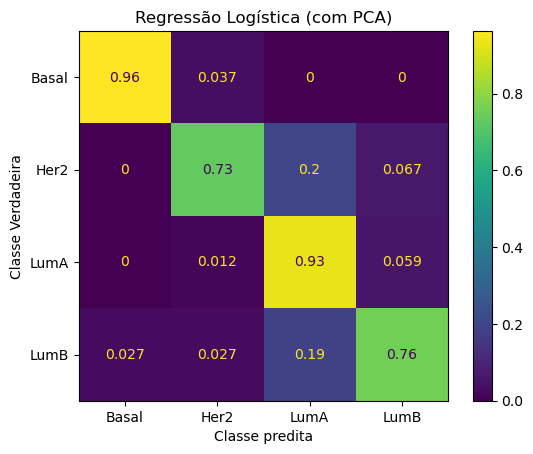

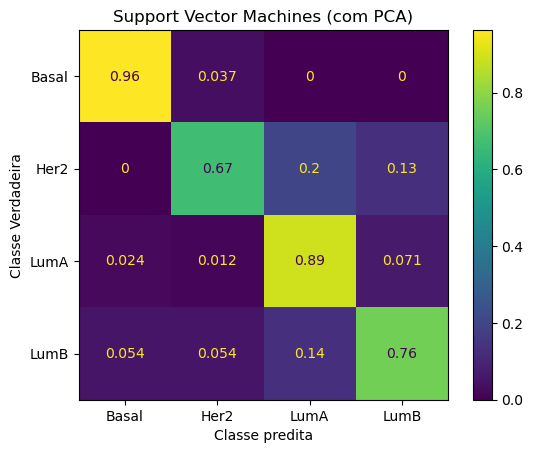

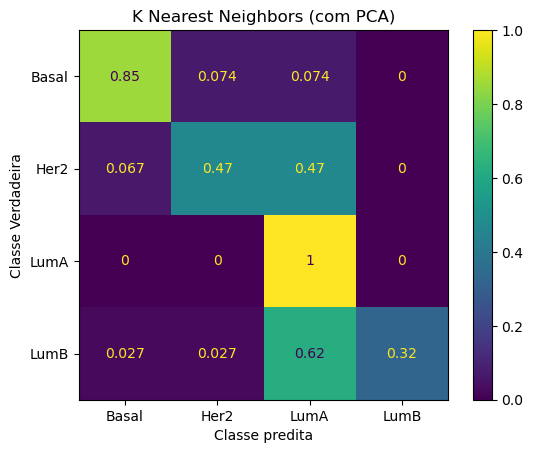

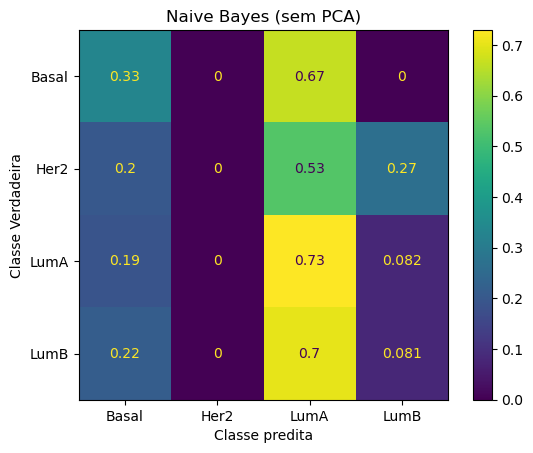

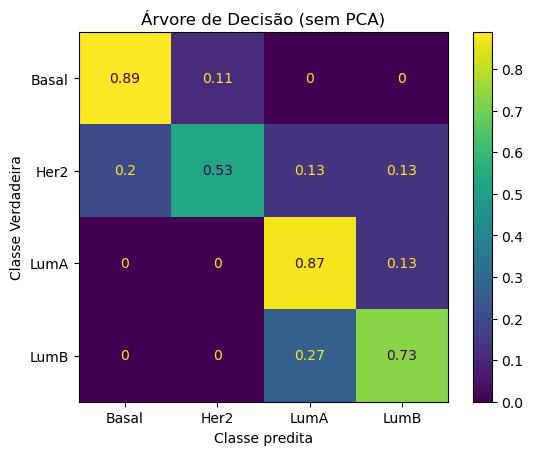

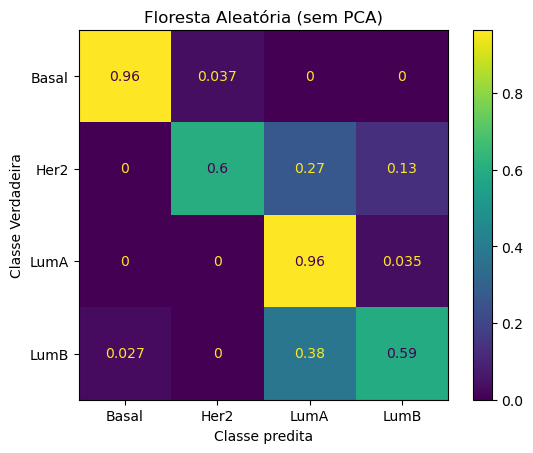

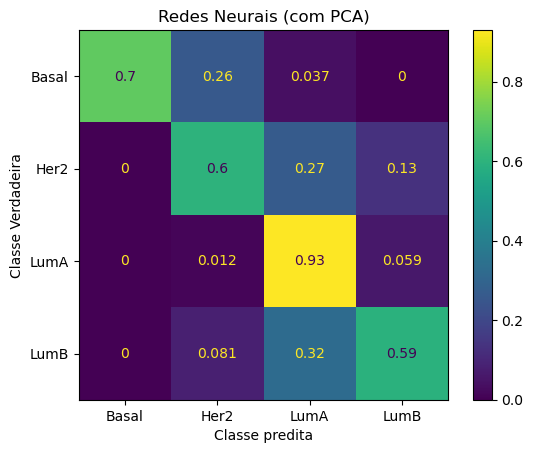

In [66]:
f1w = [sklearn.metrics.f1_score(y_teste, rl.predict(x_teste_pca), average = 'weighted'),
sklearn.metrics.f1_score(y_teste, svm.predict(x_teste_pca), average = 'weighted'),
sklearn.metrics.f1_score(y_teste, knn.predict(x_teste_pca), average = 'weighted'),
sklearn.metrics.f1_score(y_teste, nb.predict(x_teste_sc), average = 'weighted'),
sklearn.metrics.f1_score(y_teste, dt.predict(x_teste_sc), average = 'weighted'),
sklearn.metrics.f1_score(y_teste, rf.predict(x_teste_sc), average = 'weighted'),
sklearn.metrics.f1_score(y_teste_enc, np.argmax(nn.predict(x_teste_pca, verbose = 0), axis = 1), average = 'weighted')]
cmrl = ConfusionMatrixDisplay(confusion_matrix(y_teste, rl.predict(x_teste_pca), normalize='true'), display_labels=['Basal', 'Her2', 'LumA', 'LumB'])
cmsvm = ConfusionMatrixDisplay(confusion_matrix(y_teste, svm.predict(x_teste_pca), normalize='true'), display_labels=['Basal', 'Her2', 'LumA', 'LumB'])
cmknn = ConfusionMatrixDisplay(confusion_matrix(y_teste, knn.predict(x_teste_pca), normalize='true'), display_labels=['Basal', 'Her2', 'LumA', 'LumB'])
cmnb = ConfusionMatrixDisplay(confusion_matrix(y_teste, nb.predict(x_teste_sc), normalize='true'), display_labels=['Basal', 'Her2', 'LumA', 'LumB'])                   
cmdt = ConfusionMatrixDisplay(confusion_matrix(y_teste, dt.predict(x_teste_sc), normalize='true'), display_labels=['Basal', 'Her2', 'LumA', 'LumB'])
cmrf = ConfusionMatrixDisplay(confusion_matrix(y_teste, rf.predict(x_teste_sc), normalize='true'), display_labels=['Basal', 'Her2', 'LumA', 'LumB'])
cmnn = ConfusionMatrixDisplay(confusion_matrix(y_teste_enc, np.argmax(nn.predict(x_teste_pca, verbose = 0), axis = 1), normalize='true'), display_labels=['Basal', 'Her2', 'LumA', 'LumB'])
classificadores = [cmrl, cmsvm, cmknn, cmnb, cmdt, cmrf, cmnn]
nomes_c = ['Regressão Logística (com PCA)', 'Support Vector Machines (com PCA)', 'K Nearest Neighbors (com PCA)', 'Naive Bayes (sem PCA)', 'Árvore de Decisão (sem PCA)', 'Floresta Aleatória (sem PCA)', 'Redes Neurais (com PCA)']
for i in range(len(classificadores)):
    classificadores[i].plot()
    plt.title(nomes_c[i])
    plt.xlabel('Classe predita')
    plt.ylabel('Classe Verdadeira')
    plt.show()

In [116]:
print(f1w)

[0.8765019328192309, 0.8524980019476998, 0.7435470599363034, 0.3965368964107276, 0.809427272200058, 0.8389564106789718, 0.7858792392357538]


### Rascunho

In [205]:
validacao.iloc[6,2]

{'keras__model__hidden_layer_num': 1,
 'keras__model__hidden_layer_sizes': 64,
 'keras__model__regularizer': <keras.src.regularizers.regularizers.L1 at 0x1bb27253890>,
 'keras__optimizer__learning_rate': 0.1}

In [207]:
rl = LogisticRegression(penalty='l2', C = 0.01, random_state=1, solver = 'saga')
rl.fit(pd.concat([pd.DataFrame(x_treino_ac_resampled), pd.DataFrame(x_valid)]), pd.concat([y_treino_ac_resampled, y_valid]))

svm = SVC(C = 0.1, kernel = 'linear')
svm.fit(pd.concat([pd.DataFrame(x_treino_ac_resampled), pd.DataFrame(x_valid)]), pd.concat([y_treino_ac_resampled, y_valid]))

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(pd.concat([pd.DataFrame(x_treino_ac_resampled), pd.DataFrame(x_valid)]), pd.concat([y_treino_ac_resampled, y_valid]))

nb = GaussianNB()
nb.fit(pd.concat([pd.DataFrame(x_treino_ac_resampled), pd.DataFrame(x_valid)]), pd.concat([y_treino_ac_resampled, y_valid]))

nn = keras.Sequential()
nn.add(keras.Input(shape=(300,)))
nn.add(layers.Dense(64, activation='relu', kernel_regularizer = regularizers.L1(1e-2)))
nn.add(layers.Dense(4, activation="softmax"))
nn.compile(loss="sparse_categorical_crossentropy", optimizer = keras.optimizers.SGD(learning_rate=0.1), metrics = [keras.metrics.F1Score(average = 'weighted')])
nn.fit(pd.concat([pd.DataFrame(x_treino_ac_resampled), pd.DataFrame(x_valid_pca)]), pd.concat([pd.Series(y_treino_enc), pd.Series(y_valid_enc)]), epochs = 15, verbose = False, callbacks=[EarlyStopping(patience=10, restore_best_weights=True,monitor='loss')])

dt = DecisionTreeClassifier(max_depth = 10, min_samples_split = 2, random_state = 1)
dt.fit(pd.concat([pd.DataFrame(x_treino_ac_resampled), pd.DataFrame(x_valid_ac)]), pd.concat([y_treino_ac_res, y_valid]))

rf = RandomForestClassifier(n_estimators = 100, max_depth = 10, min_samples_split = 10, random_state = 1)
rf.fit(pd.concat([pd.DataFrame(x_treino_ac_resampled), pd.DataFrame(x_valid_ac)]), pd.concat([y_treino, y_valid]))

TypeError: Feature names are only supported if all input features have string names, but your input has ['int', 'str'] as feature name / column name types. If you want feature names to be stored and validated, you must convert them all to strings, by using X.columns = X.columns.astype(str) for example. Otherwise you can remove feature / column names from your input data, or convert them all to a non-string data type.

In [ ]:
f1w = [sklearn.metrics.f1_score(y_teste, rl.predict(x_teste_ac), average = 'weighted'),
sklearn.metrics.f1_score(y_teste, svm.predict(x_teste_ac), average = 'weighted'),
sklearn.metrics.f1_score(y_teste, knn.predict(x_teste_ac), average = 'weighted'),
sklearn.metrics.f1_score(y_teste, nb.predict(x_teste_ac), average = 'weighted'),
sklearn.metrics.f1_score(y_teste, dt.predict(x_teste_ac), average = 'weighted'),
sklearn.metrics.f1_score(y_teste, rf.predict(x_teste_ac), average = 'weighted'),
sklearn.metrics.f1_score(y_teste_enc, np.argmax(nn.predict(x_teste_ac, verbose = 0), axis = 1), average = 'weighted')]
cmrl = ConfusionMatrixDisplay(confusion_matrix(y_teste, rl.predict(x_teste_ac), normalize='true'), display_labels=['Basal', 'Her2', 'LumA', 'LumB'])
cmsvm = ConfusionMatrixDisplay(confusion_matrix(y_teste, svm.predict(x_teste_ac), normalize='true'), display_labels=['Basal', 'Her2', 'LumA', 'LumB'])
cmknn = ConfusionMatrixDisplay(confusion_matrix(y_teste, knn.predict(x_teste_ac), normalize='true'), display_labels=['Basal', 'Her2', 'LumA', 'LumB'])
cmnb = ConfusionMatrixDisplay(confusion_matrix(y_teste, nb.predict(x_teste_ac), normalize='true'), display_labels=['Basal', 'Her2', 'LumA', 'LumB'])                   
cmdt = ConfusionMatrixDisplay(confusion_matrix(y_teste, dt.predict(x_teste_ac), normalize='true'), display_labels=['Basal', 'Her2', 'LumA', 'LumB'])
cmrf = ConfusionMatrixDisplay(confusion_matrix(y_teste, rf.predict(x_teste_ac), normalize='true'), display_labels=['Basal', 'Her2', 'LumA', 'LumB'])
cmnn = ConfusionMatrixDisplay(confusion_matrix(y_teste_enc, np.argmax(nn.predict(x_teste_pca, verbose = 0), axis = 1), normalize='true'), display_labels=['Basal', 'Her2', 'LumA', 'LumB'])
classificadores = [cmrl, cmsvm, cmknn, cmnb, cmdt, cmrf, cmnn]
nomes_c = ['Regressão Logística (com PCA)', 'Support Vector Machines (com PCA)', 'K Nearest Neighbors (com PCA)', 'Naive Bayes (sem PCA)', 'Árvore de Decisão (sem PCA)', 'Floresta Aleatória (sem PCA)', 'Redes Neurais (com PCA)']
for i in range(len(classificadores)):
    classificadores[i].plot()
    plt.title(nomes_c[i])
    plt.xlabel('Classe predita')
    plt.ylabel('Classe Verdadeira')
    plt.show()

In [182]:
nn = keras.Sequential()
nn.add(keras.Input(shape=(300,)))
nn.add(layers.Dense(16, activation='relu', kernel_regularizer = regularizers.L1(1e-2)))
nn.add(layers.Dense(16, activation='relu', kernel_regularizer = regularizers.L1(1e-2)))
nn.add(layers.Dense(16, activation='relu', kernel_regularizer = regularizers.L1(1e-2)))
nn.add(layers.Dense(4, activation="softmax"))
nn.compile(loss="sparse_categorical_crossentropy", optimizer = keras.optimizers.SGD(learning_rate=0.1), metrics = ['accuracy'])
nn.fit(x_treino_pca, y_treino_enc, epochs = 15, verbose = False, callbacks=[EarlyStopping(patience=10, restore_best_weights=True,monitor='loss')])
nn.save(filepath='nnteste.keras')

In [177]:
y_valid_enc = ee.transform(y_valid)

In [184]:
nn.evaluate(x_valid_pca, y_valid_enc)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8652 - loss: 1.0108


[1.0330554246902466, 0.8650306463241577]

In [ ]:
print(confusion_matrix(np.argmax(nn.predict(x_valid_pca, verbose = 0), axis = 1), y_valid_enc))
print(classification_report(np.argmax(nn.predict(x_valid_pca, verbose = 0), axis = 1), y_valid_enc))

In [57]:
from sklearn.tree import DecisionTreeClassifier

In [59]:
tree = DecisionTreeClassifier()

In [65]:
tree.fit(x_valid, y_valid)

DecisionTreeClassifier()

In [66]:
tree.score(x_train, y_test)

1.0

In [74]:
print(nn.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 20)             │     1,213,220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │            84 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,213,726 (4.63 MB)

 Trainable params: 1,213,724 (4.63 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

None


In [76]:
dados_central_genes = dados_central.iloc[:, 5:]

In [77]:
filtro1 = (dados_central_genes >= 1).sum(axis = 0) >= (dados_central_genes.shape[0]/2)

In [80]:
filtro1.head()

ENSG00000000003.15     True
ENSG00000000005.6     False
ENSG00000000419.13     True
ENSG00000000457.14     True
ENSG00000000460.17     True
dtype: bool

In [81]:
dados_central_filtro1 = dados_central_genes.loc[:, filtro1]

In [82]:
sdtf1 = dados_central_filtro1.std(axis = 0) 

In [83]:
sdtf1.quantile(.75)

25.077591343559945

In [84]:
dados_central_filtro2 = dados_central_filtro1.loc[:, sdtf1 >= sdtf1.quantile(.75)]

In [85]:
cv = dados_central_filtro2.std(axis = 0) / dados_central_filtro2.mean(axis = 0)

In [86]:
dados_central_filtro3 = dados_central_filtro2.loc[:, cv >= cv.quantile(.75)]

In [87]:
genes_filtro3 = dados_central_filtro3.columns.tolist()

In [148]:
x_train, y_train = dados_central_filtro3.iloc[:, :], dados_central['subtipo2']
x_test, y_test = dados_central_filtro3.iloc[:, :], dados_central['subtipo2']
ee = LabelEncoder()
ee2 = LabelEncoder()
y_train = ee.fit_transform(y_train)
y_test = ee2.fit_transform(y_test)

In [89]:
from keras import layers

In [ ]:
nn = keras.Sequential()
nn.add(keras.Input(shape=(100,)))
nn.add(layers.Dense(16, activation='relu', kernel_regularizer = regularizers.L1(1e-2)))
nn.add(layers.Dense(16, activation='relu', kernel_regularizer = regularizers.L1(1e-2)))
nn.add(layers.Dense(4, activation="softmax"))
nn.compile(loss="sparse_categorical_crossentropy", optimizer = keras.optimizers.SGD(learning_rate=0.1), metrics = ['accuracy'])
nn.fit(x_train, y_train, epochs = 10, verbose = False, callbacks=[EarlyStopping(patience=10, restore_best_weights=True,monitor='loss')])
nn.save(filepath='nnteste.keras')

In [143]:
nn.evaluate(x_valid, y_valid)

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5501 - loss: 11137004.0000


[11137004.0, 0.5153374075889587]

In [120]:
from sklearn.decomposition import PCA

In [151]:
pca = PCA(n_components=100)
x_train = pca.fit_transform(x_train)
x_test = pca.fit_transform(x_test)

In [145]:
x_train.shape

(1072, 50)